$$ ITI \space AI-Pro: \space Intake \space 45 $$
$$ Machine \space Learning \space 1 $$
$$ Lab \space no. \space 3 $$

# `01` Import Necessary Libraries

## `i` Default Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

## `ii` Additional Libraries
Add imports for additional libraries you used throughout the notebook

In [2]:
import warnings
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score,precision_score,f1_score,confusion_matrix
warnings.filterwarnings("ignore")


----------------------------

# `02` Load Data

Note: Make sure the `Data` folder attached with the notebook is in the same path for this cell to work properly.

[Dataset Link](https://www.kaggle.com/datasets/parisrohan/credit-score-classification)

In [3]:
# prompt: connect with drive

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
train = pd.read_csv('/content/drive/MyDrive/credit_data/train.csv')
test = pd.read_csv('/content/drive/MyDrive/credit_data/test.csv')

In [5]:
train.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [6]:
train.shape

(100000, 28)

In [7]:
test.shape

(50000, 27)

----------------

# `03` Exploratory Data Analysis (EDA)

## `i` Simple Analysis

Preview data, perform statistical data analysis and explore as much as needed to better understand the data set we're dealing with.

`Notes:`
- Feel free to look up EDA approaches online for inspiration (however you **must understand** everything and not copy paste).
- Make sure to add notes and insights extracted from your analysis.


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [9]:
train.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,9985
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,15002
Num_Bank_Accounts,0


### there are missing value will prepare it in preparation stage

In [10]:
train.duplicated().sum()

0

In [11]:
train['Credit_Score'].value_counts()

,count
Credit_Score,
Standard,53174
Poor,28998
Good,17828


In [12]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Inhand_Salary,84998.0,4194.170850,3183.686167,303.645417,1625.568229,3093.745000,5957.448333,15204.633333
Num_Bank_Accounts,100000.0,17.091280,117.404834,-1.000000,3.000000,6.000000,7.000000,1798.000000
Num_Credit_Card,100000.0,22.474430,129.057410,0.000000,4.000000,5.000000,7.000000,1499.000000
Interest_Rate,100000.0,72.466040,466.422621,1.000000,8.000000,13.000000,20.000000,5797.000000
Delay_from_due_date,100000.0,21.068780,14.860104,-5.000000,10.000000,18.000000,28.000000,67.000000
Num_Credit_Inquiries,98035.0,27.754251,193.177339,0.000000,3.000000,6.000000,9.000000,2597.000000
Credit_Utilization_Ratio,100000.0,32.285173,5.116875,20.000000,28.052567,32.305784,36.496663,50.000000
Total_EMI_per_month,100000.0,1403.118217,8306.041270,0.000000,30.306660,69.249473,161.224249,82331.000000


----------------

# `03` Data Preparation

Perform data cleaning, feature engineering, scaling, dropping unwanted columns (such as IDs), etc. as needed to make sure it's ready for the model.

`Q` Is this dataset *skewed*?

Hint: It could be helpful to check `sklearn.preprocessing` module.

In [13]:
train.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [14]:
train['Month'].value_counts()

,count
Month,
January,12500
February,12500
March,12500
April,12500
May,12500
June,12500
July,12500
August,12500


# Occupation column

In [15]:
train['Occupation'].value_counts()

,count
Occupation,
_______,7062
Lawyer,6575
Architect,6355
Engineer,6350
Scientist,6299
Mechanic,6291
Accountant,6271
Developer,6235
Media_Manager,6232


In [16]:
train.groupby('Customer_ID')['Occupation'].value_counts().reset_index(name='Count')


,Customer_ID,Occupation,Count
0,CUS_0x1000,Lawyer,8
1,CUS_0x1009,Mechanic,7
2,CUS_0x1009,_______,1
3,CUS_0x100b,Media_Manager,8
4,CUS_0x1011,Doctor,8
...,...,...,...
18045,CUS_0xff6,Doctor,8
18046,CUS_0xffc,Musician,7
18047,CUS_0xffc,_______,1
18048,CUS_0xffd,Scientist,7


In [17]:
occupation_mapping = train[train['Occupation'] != "_______"].groupby('Customer_ID')['Occupation'].first()
train['Occupation'] = train.apply(lambda row: occupation_mapping[row['Customer_ID']] if row['Occupation'] == "_______" else row['Occupation'], axis=1)


In [18]:
train['Occupation'].value_counts()

,count
Occupation,
Lawyer,7096
Engineer,6864
Architect,6824
Mechanic,6776
Scientist,6744
Accountant,6744
Developer,6720
Media_Manager,6720
Teacher,6672


# Age column

In [19]:
train['Age'] = train['Age'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)
train['Age']=train['Age'].astype(int)

In [20]:
train['Age'].dtype

dtype('int64')

In [21]:
Age_new=train[(train['Age'] >0) & (train['Age'] <= 65)].groupby('Customer_ID')['Age'].first()
train['Age'] = train.apply(lambda row: Age_new[row['Age']] if (row['Age'] <0) | (row['Age'] >=65)  else row['Age'], axis=1)

In [22]:
train['Age'].describe()

,Age
count,100000.00000
mean,33.17262
std,10.83257
min,14.00000
25%,24.00000
50%,33.00000
75%,42.00000
max,56.00000


# Annual_Income Column

In [23]:
print(list(train['Annual_Income'].unique()))



['19114.12', '34847.84', '34847.84_', '143162.64', '30689.89', '30689.89_', '35547.71_', '35547.71', '73928.46', '131313.4', '10909427.0', '34081.38_', '34081.38', '114838.41', '114838.41_', '31370.8', '33751.27', '88640.24', '88640.24_', '54392.16', '54392.16_', '8701.545', '8701.545_', '25546.26', '25546.26_', '31993.78', '92047.08', '92047.08_', '32284.62', '97791.42', '97791.42_', '19300.34', '19514.88', '10183.015', '10183.015_', '106733.13', '106733.13_', '12600.445', '12600.445_', '57983.12', '57983.12_', '20787.69', '34290.12', '34290.12_', '43070.24', '43070.24_', '28572.39', '6515990.0_', '39641.54', '39641.54_', '20186.02', '586359.0', '18627.64', '12986.745', '58317.0', '42171.98', '71681.4', '29469.98', '29469.98_', '72559.36', '15566.02', '15566.02_', '66567.32', '12909.895', '30788.44', '20574.47', '20574.47_', '148699.32', '148699.32_', '85554.03', '55829.79', '18334118.0', '19717385.0', '14165.23', '14165.23_', '87215.68', '2709655.0', '81842.28', '81842.28_', '95956.5

In [24]:
x='65000.73_'
x[-1]

'_'

In [25]:
train['Annual_Income'].dtype

dtype('O')

In [26]:

train['Annual_Income'] = train['Annual_Income'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)


In [27]:
train['Annual_Income']=train['Annual_Income'].astype(float)

In [28]:
train['Annual_Income'].dtype

dtype('float64')

In [29]:
train['Annual_Income'].isna().sum()

0

# Monthly_Inhand_Salary column

In [30]:
train['Monthly_Inhand_Salary'].dtype

dtype('float64')

In [31]:
Salary=train.groupby('Customer_ID')['Monthly_Inhand_Salary'].first()
Salary

,Monthly_Inhand_Salary
Customer_ID,
CUS_0x1000,2706.161667
CUS_0x1009,4250.390000
CUS_0x100b,9549.782500
CUS_0x1011,5208.872500
CUS_0x1013,7962.415000
...,...
CUS_0xff3,1176.398750
CUS_0xff4,2415.855000
CUS_0xff6,9727.326667


In [32]:
train['Monthly_Inhand_Salary']=train.apply(lambda row: Salary[row['Customer_ID']] if str(row['Monthly_Inhand_Salary'])=='nan' else row['Monthly_Inhand_Salary'],axis=1)

In [33]:
train['Monthly_Inhand_Salary'].isna().sum()

0

# Num_Bank_Accounts column

In [34]:

train['Num_Bank_Accounts'].dtype


dtype('int64')

In [35]:
train['Num_Bank_Accounts'].describe()

,Num_Bank_Accounts
count,100000.000000
mean,17.091280
std,117.404834
min,-1.000000
25%,3.000000
50%,6.000000
75%,7.000000
max,1798.000000


In [36]:
train['Num_Bank_Accounts'].isna().sum()

0

In [37]:
train['Num_Bank_Accounts'] = train['Num_Bank_Accounts'].apply(lambda x: abs(x) if x<0 else x)

# Num_Credit_Card

In [38]:
train['Num_Credit_Card'].dtype

dtype('int64')

In [39]:
train['Num_Credit_Card'].describe()

,Num_Credit_Card
count,100000.00000
mean,22.47443
std,129.05741
min,0.00000
25%,4.00000
50%,5.00000
75%,7.00000
max,1499.00000


# Interest_Rate column

In [40]:
print(train['Interest_Rate'].describe())


count    100000.000000
mean         72.466040
std         466.422621
min           1.000000
25%           8.000000
50%          13.000000
75%          20.000000
max        5797.000000
Name: Interest_Rate, dtype: float64


In [41]:
train['Interest_Rate'].dtype

dtype('int64')

# Num_of_Loan column

In [42]:

train['Num_of_Loan'] = train['Num_of_Loan'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)
train['Num_of_Loan']=train['Num_of_Loan'].astype(int)

In [43]:
train['Num_of_Loan'].describe()


,Num_of_Loan
count,100000.000000
mean,3.009960
std,62.647879
min,-100.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,1496.000000


In [44]:
train['Num_of_Loan']=train['Num_of_Loan'].apply(lambda x: abs(x) if x<0 else x  )

# Type_of_Loan column

In [45]:
loans=train.groupby('Customer_ID')['Type_of_Loan'].value_counts().reset_index(name='Count')
loans

,Customer_ID,Type_of_Loan,Count
0,CUS_0x1000,"Credit-Builder Loan, and Home Equity Loan",8
1,CUS_0x1009,"Not Specified, Home Equity Loan, Credit-Builde...",8
2,CUS_0x1011,"Student Loan, Credit-Builder Loan, and Debt Co...",8
3,CUS_0x1013,"Student Loan, Debt Consolidation Loan, and Per...",8
4,CUS_0x1018,"Credit-Builder Loan, Payday Loan, Home Equity ...",8
...,...,...,...
11069,CUS_0xff3,"Personal Loan, Mortgage Loan, and Auto Loan",8
11070,CUS_0xff4,"Not Specified, Student Loan, Student Loan, Cre...",8
11071,CUS_0xff6,"Home Equity Loan, and Auto Loan",8
11072,CUS_0xffc,"Credit-Builder Loan, Payday Loan, Not Specifie...",8


In [46]:
loans.head()

,Customer_ID,Type_of_Loan,Count
0,CUS_0x1000,"Credit-Builder Loan, and Home Equity Loan",8
1,CUS_0x1009,"Not Specified, Home Equity Loan, Credit-Builde...",8
2,CUS_0x1011,"Student Loan, Credit-Builder Loan, and Debt Co...",8
3,CUS_0x1013,"Student Loan, Debt Consolidation Loan, and Per...",8
4,CUS_0x1018,"Credit-Builder Loan, Payday Loan, Home Equity ...",8


In [53]:
train.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,9985
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


# Delay_from_due_date column

In [54]:
train['Delay_from_due_date'].dtype

dtype('int64')

In [55]:
train['Delay_from_due_date'].describe()

,Delay_from_due_date
count,100000.000000
mean,21.068780
std,14.860104
min,-5.000000
25%,10.000000
50%,18.000000
75%,28.000000
max,67.000000


In [56]:
train['Delay_from_due_date'] = train['Delay_from_due_date'].apply(lambda x: abs(x) if x<0 else x)

In [57]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=2)
train['Delay_from_due_date'] = imputer.fit_transform(train[['Delay_from_due_date']])

In [58]:
train['Delay_from_due_date']=train['Delay_from_due_date'].astype(int)

In [59]:
train['Delay_from_due_date'].isna().sum()

0

In [60]:
train.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,9985
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


# Num_of_Loan column

In [61]:
train['Num_of_Loan'].dtype

dtype('int64')

In [62]:
train['Num_of_Loan'] = train['Num_of_Loan'].apply(lambda x: abs(x) if x<0 else x)

In [63]:
train['Num_of_Loan'].isna().sum()

0

# Num_of_Delayed_Payment column

In [64]:
train['Num_of_Delayed_Payment'] = train['Num_of_Delayed_Payment'].astype(str)
train['Num_of_Delayed_Payment'] = train['Num_of_Delayed_Payment'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)


In [65]:
train['Num_of_Delayed_Payment'].dtype

dtype('O')

In [66]:

imputer = KNNImputer(n_neighbors=2)
train['Num_of_Delayed_Payment'] = imputer.fit_transform(train[['Num_of_Delayed_Payment']])

In [67]:
train['Num_of_Delayed_Payment'] = train['Num_of_Delayed_Payment'].astype(int)
train['Num_of_Delayed_Payment'] = train['Num_of_Delayed_Payment'].apply(lambda x: abs(x) if x<0 else x)


In [68]:
train['Num_of_Delayed_Payment'].isna().sum()

0

In [69]:
train.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,9985
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


In [70]:
train['Num_of_Delayed_Payment'].dtype

dtype('int64')

In [71]:
train.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,9985
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


# Delay_from_due_date

In [72]:
train['Delay_from_due_date'] = train['Delay_from_due_date'].apply(lambda x: abs(x) if x<0 else x)

# Changed_Credit_Limit

In [73]:
print(list(train['Changed_Credit_Limit'].unique()))



['11.27', '_', '6.27', '9.27', '5.42', '7.42', '6.42', '7.1', '11.1', '9.1', '1.99', '-2.01', '-1.01', '-3.01', '2.58', '10.14', '9.14', '9.34', '15.34', '8.34', '11.34', '17.13', '21.13', '18.13', '8.24', '11.24', '5.76', '-1.2400000000000002', '1.7599999999999998', '11.0', '8.0', '3.51', '5.54', '4.54', '0.54', '11.54', '8.86', '7.83', '10.83', '6.28', '10.28', '9.13', '13.13', '9.22', '8.22', '2.2200000000000006', '17.92', '11.920000000000002', '15.920000000000002', '13.920000000000002', '9.95', '15.95', '8.95', '4.17', '8.969999999999997', '7.97', '10.97', '0.86', '-4.14', '-0.14', '15.79', '21.79', '7.27', '10.27', '1.13', '-2.87', '8.129999999999999', '17.96', '13.96', '12.96', '8.97', '14.97', '12.97', '4.9700000000000015', '4.89', '1.54', '-2.46', '6.83', '0.8300000000000001', '5.07', '6.07', '11.8', '16.8', '16.58', '10.579999999999998', '23.58', '22.58', '21.58', '9.58', '10.44', '4.44', '26.94', '22.94', '27.94', '2.74', '-4.26', '-1.2599999999999998', '9.24', '7.67', '5.67'

In [74]:
train['Changed_Credit_Limit']=train['Changed_Credit_Limit'].apply(lambda x:'nan' if x=='_' else x)
train['Changed_Credit_Limit'] = imputer.fit_transform(train[['Changed_Credit_Limit']])
train['Changed_Credit_Limit']=train['Changed_Credit_Limit'].astype(float)


# Num_Credit_Inquiries

In [112]:
train['Num_Credit_Inquiries'].dtype

dtype('O')

In [76]:
credit=train.groupby('Customer_ID')['Num_Credit_Inquiries'].value_counts()

In [77]:
train['Num_Credit_Inquiries']=train.apply(lambda row: credit[row['Customer_ID']] if str(row['Num_Credit_Inquiries'])=='nan' else row['Num_Credit_Inquiries'],axis=1)


In [78]:
train['Num_Credit_Inquiries'].isna().sum()



0

In [79]:
train.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,9985
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


# Credit_Mix Column

In [80]:
train['Credit_Mix'].value_counts()

,count
Credit_Mix,
Standard,36479
Good,24337
_,20195
Bad,18989


In [81]:
train['Credit_Mix']=train['Credit_Mix'].apply(lambda x:'Other' if x=='_' else x )

In [82]:
train['Credit_Mix'].value_counts()

,count
Credit_Mix,
Standard,36479
Good,24337
Other,20195
Bad,18989


# Outstanding_Debt column

In [83]:
train['Outstanding_Debt'] = train['Outstanding_Debt'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)

In [84]:
train['Outstanding_Debt']=train['Outstanding_Debt'].astype(float)

In [85]:
train['Credit_Utilization_Ratio'].dtype

dtype('float64')

# Payment_of_Min_Amount column

In [86]:
train['Payment_of_Min_Amount']=train['Payment_of_Min_Amount'].apply(lambda x: 'No' if x=='NM' else x)

In [87]:
train['Payment_of_Min_Amount'].value_counts()

,count
Payment_of_Min_Amount,
Yes,52326
No,47674


In [88]:
train['Total_EMI_per_month'].dtype

dtype('float64')

# Amount_invested_monthly column

In [89]:
train['Amount_invested_monthly'].unique()

array(['80.41529543900253', '118.28022162236736', '81.699521264648', ...,
       '24.02847744864441', '251.67258219721603', '167.1638651610451'],
      dtype=object)

In [90]:
train['Amount_invested_monthly']=train['Amount_invested_monthly'].apply(lambda x:'10000' if x=='__10000__' else x)

In [91]:
train['Amount_invested_monthly']=train['Amount_invested_monthly'].astype(float)

In [92]:

train['Amount_invested_monthly'].fillna(train['Amount_invested_monthly'].mean(),inplace=True)


# Monthly_Balance column

In [93]:
train['Monthly_Balance']=train['Monthly_Balance'].apply(lambda x:'nan' if x=='__-333333333333333333333333333__' else x)

In [94]:
train['Monthly_Balance']=train['Monthly_Balance'].astype(float)

In [95]:
train['Monthly_Balance'].fillna(train['Monthly_Balance'].mean(),inplace=True)

# Payment_Behaviour column

In [96]:
train['Payment_Behaviour']=train['Payment_Behaviour'].apply(lambda x:'Other' if x=='!@9#%8' else x)

In [97]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  int64  
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  int64  
 13  Type_of_Loan              88592 non-null   ob

In [98]:
train.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,9985
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


# Credit_History_Age

In [99]:
train['Credit_History_Age'].fillna('Unknown',inplace=True)

In [100]:
history_age = []
for i in range(train.shape[0]):
    if ('Years and') in train['Credit_History_Age'].values[i]:
        splitted = train['Credit_History_Age'].values[i].split('Years and')
        years = int(splitted[0].strip())
        months = int(splitted[1].replace('Months', ''))
        history_age.append((years * 12) + months)
    else:
        history_age.append(0)

train['Credit_History_Age'] = history_age

In [101]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  int64  
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  int64  
 13  Type_of_Loan              88592 non-null   ob

In [102]:
train.shape

(100000, 28)

In [111]:
train.select_dtypes('object').columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'SSN', 'Occupation',
       'Type_of_Loan', 'Num_Credit_Inquiries', 'Credit_Mix',
       'Payment_of_Min_Amount', 'Payment_Behaviour', 'Credit_Score'],
      dtype='object')

# Visual Analysis

Plot graphs and relations in order to gain more insights about the data set, identify patterns, and make assumptions.

`Notes:`
- Feel free to look up visual EDA approaches online for inspiration (however you **must understand** everything and not copy paste).
- Make sure to add notes and insights extracted from your analysis.

<Axes: xlabel='Credit_Score', ylabel='count'>

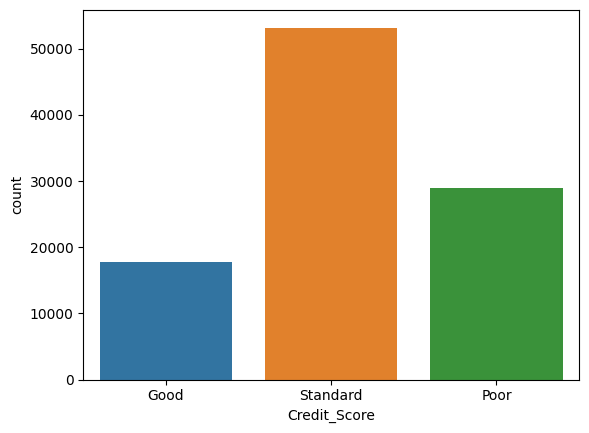

In [116]:
sns.countplot(data=train,x='Credit_Score',palette='tab10')

<Axes: xlabel='count', ylabel='Occupation'>

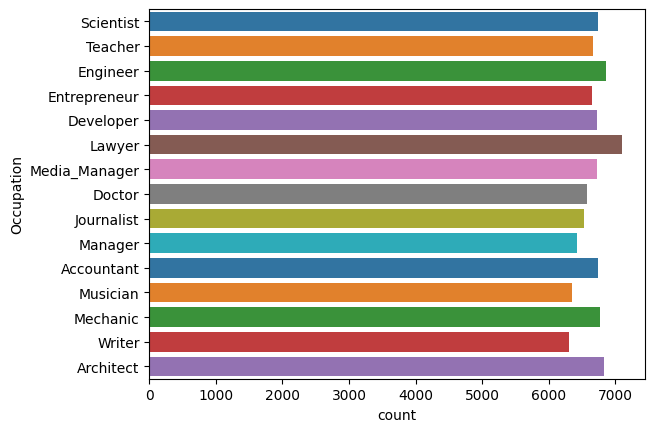

In [117]:
sns.countplot(data=train,y='Occupation',palette='tab10')

<Axes: xlabel='Credit_Mix', ylabel='count'>

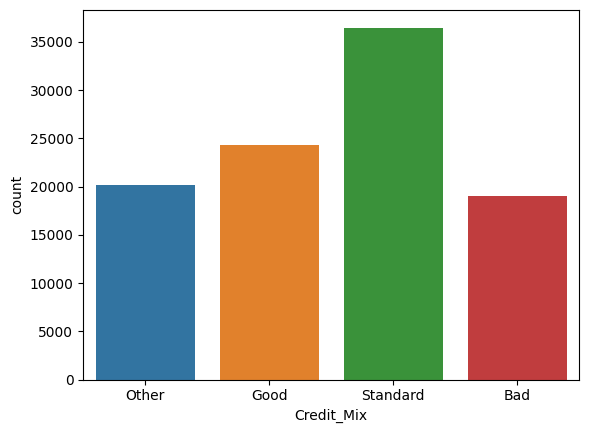

In [118]:
sns.countplot(data=train,x='Credit_Mix',palette='tab10')

<Axes: xlabel='count', ylabel='Payment_Behaviour'>

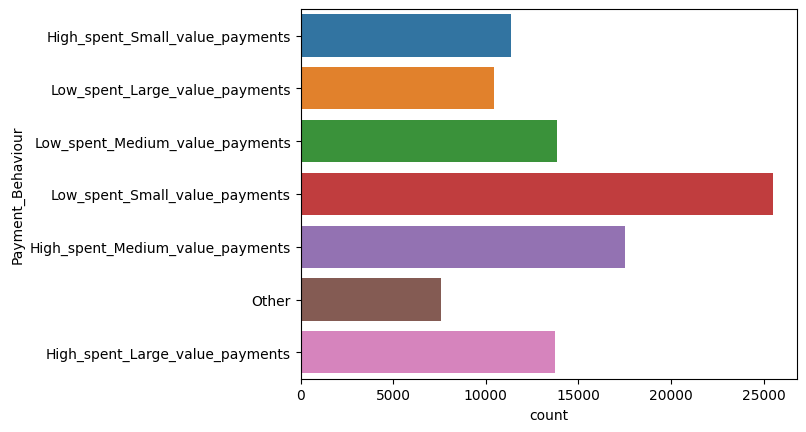

In [120]:
sns.countplot(data=train,y='Payment_Behaviour',palette='tab10')

<Axes: xlabel='Payment_of_Min_Amount', ylabel='count'>

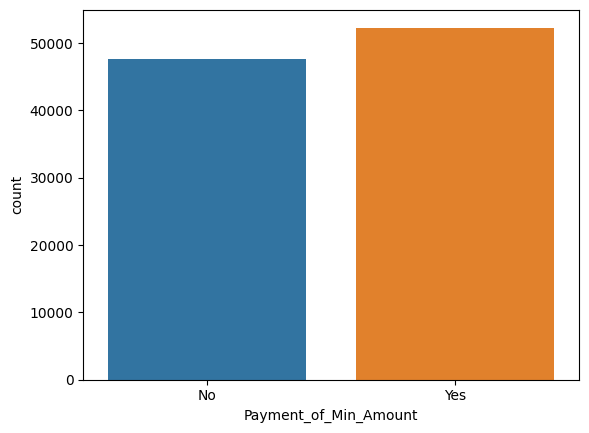

In [122]:
sns.countplot(data=train,x='Payment_of_Min_Amount',palette='tab10')

<Axes: xlabel='Credit_Score', ylabel='count'>

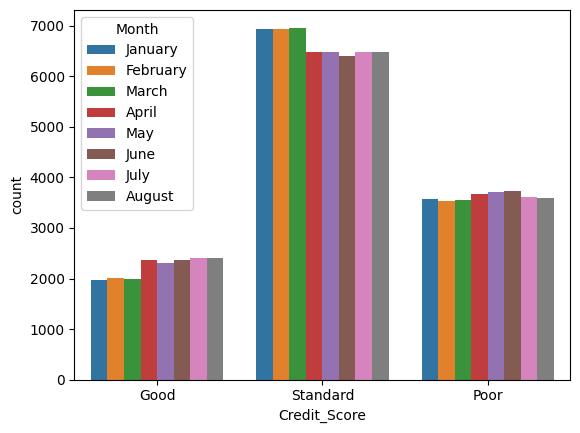

In [123]:
sns.countplot(data=train,x='Credit_Score',palette='tab10',hue='Month')

<Axes: xlabel='Age', ylabel='Count'>

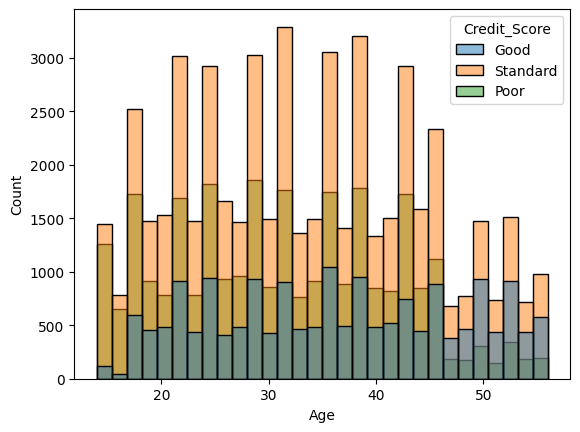

In [133]:
sns.histplot(data=train, x='Age', hue='Credit_Score', bins=30)

<Axes: xlabel='Monthly_Inhand_Salary', ylabel='Count'>

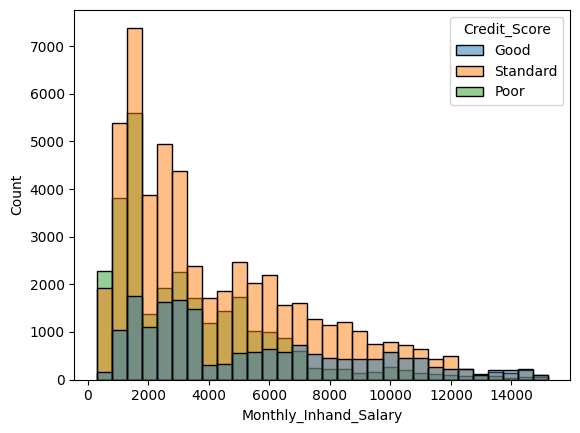

In [134]:
sns.histplot(data=train, x='Monthly_Inhand_Salary', hue='Credit_Score', bins=30)

<Axes: xlabel='Num_Credit_Card', ylabel='Count'>

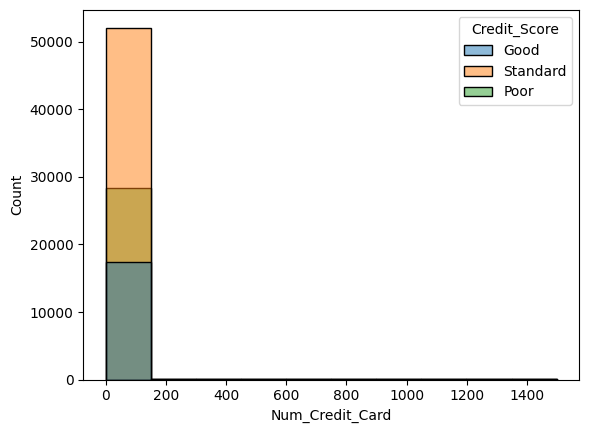

In [137]:
sns.histplot(data=train, x='Num_Credit_Card', hue='Credit_Score',bins=10)

<Axes: xlabel='Credit_Score', ylabel='Delay_from_due_date'>

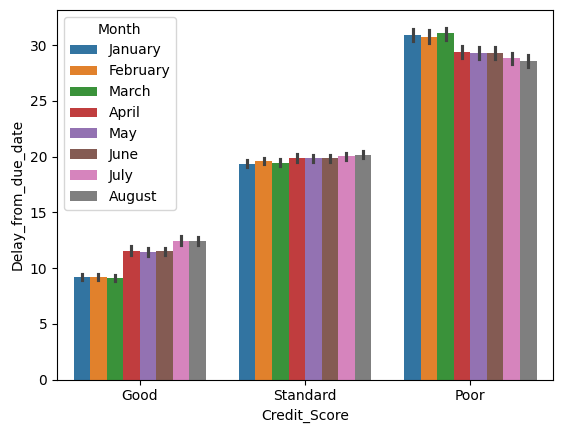

In [140]:
sns.barplot(data=train,x='Credit_Score',y='Delay_from_due_date',hue='Month')

<Axes: xlabel='Credit_Score', ylabel='Outstanding_Debt'>

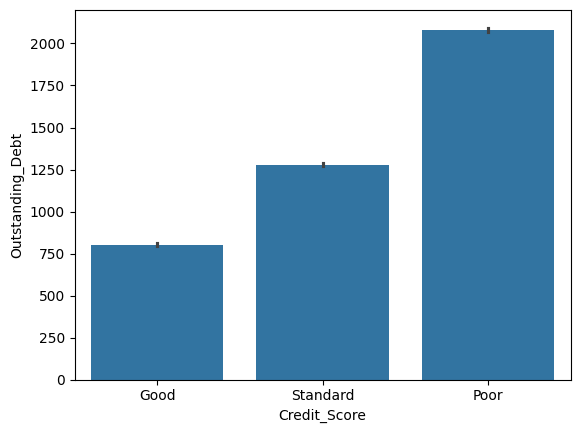

In [141]:
sns.barplot(data=train,x='Credit_Score',y='Outstanding_Debt')

<Axes: xlabel='Credit_Score', ylabel='Changed_Credit_Limit'>

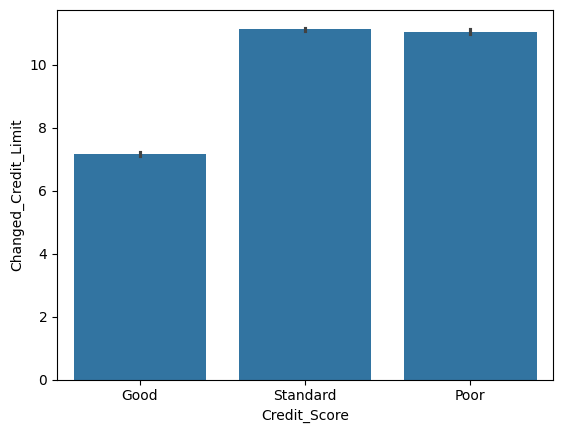

In [142]:
sns.barplot(data=train,x='Credit_Score',y='Changed_Credit_Limit')

<Axes: xlabel='Credit_Score', ylabel='Num_of_Loan'>

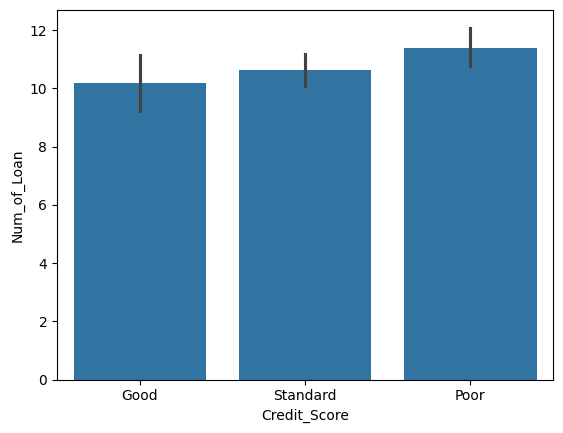

In [144]:
sns.barplot(data=train,x='Credit_Score',y='Num_of_Loan')

<Axes: xlabel='Credit_Score', ylabel='Num_Bank_Accounts'>

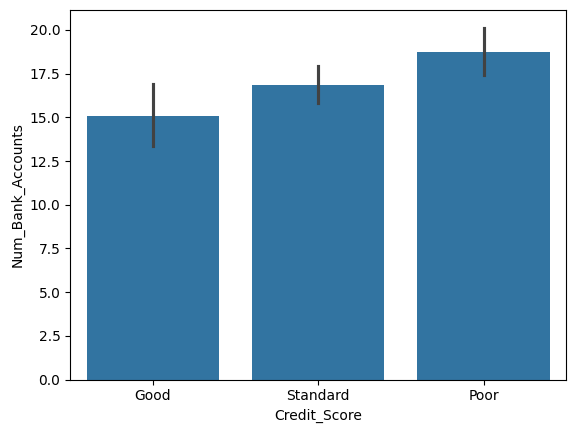

In [145]:
sns.barplot(data=train,x='Credit_Score',y='Num_Bank_Accounts')

<Axes: xlabel='Age', ylabel='Monthly_Inhand_Salary'>

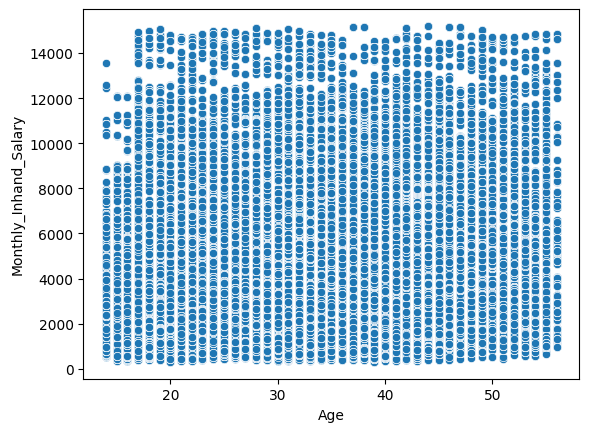

In [147]:
sns.scatterplot(data=train,x='Age',y='Monthly_Inhand_Salary')

<Axes: xlabel='Num_Bank_Accounts', ylabel='Num_Credit_Card'>

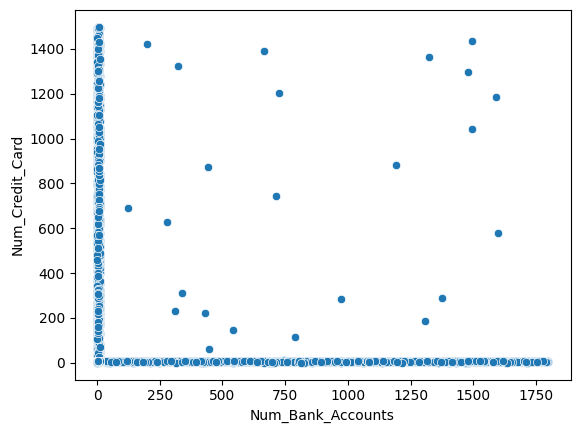

In [149]:
sns.scatterplot(data=train,x='Num_Bank_Accounts',y='Num_Credit_Card')

<Axes: xlabel='Num_of_Loan', ylabel='Delay_from_due_date'>

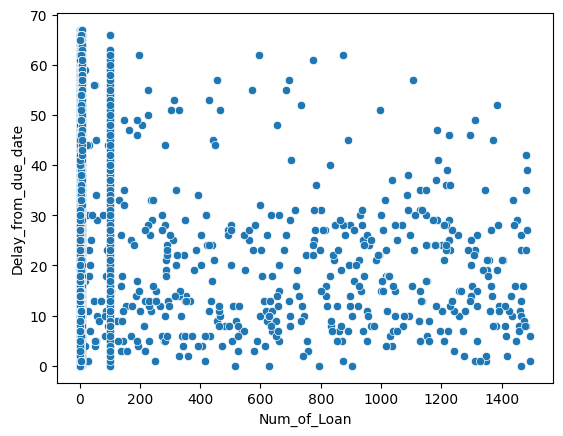

In [150]:
sns.scatterplot(data=train,x='Num_of_Loan',y='Delay_from_due_date')

<Axes: xlabel='Amount_invested_monthly', ylabel='Count'>

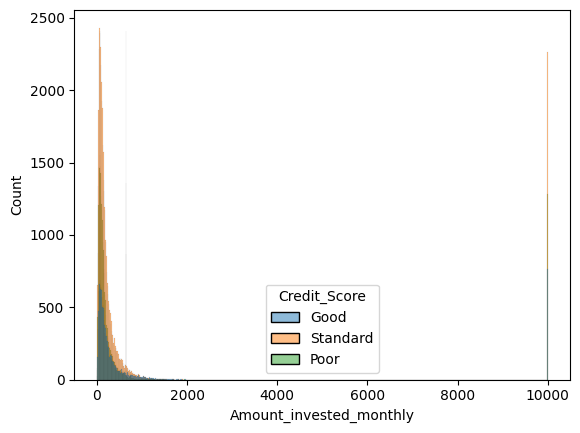

In [151]:
sns.histplot(data=train,x='Amount_invested_monthly',hue='Credit_Score')

<Axes: xlabel='Credit_History_Age', ylabel='Count'>

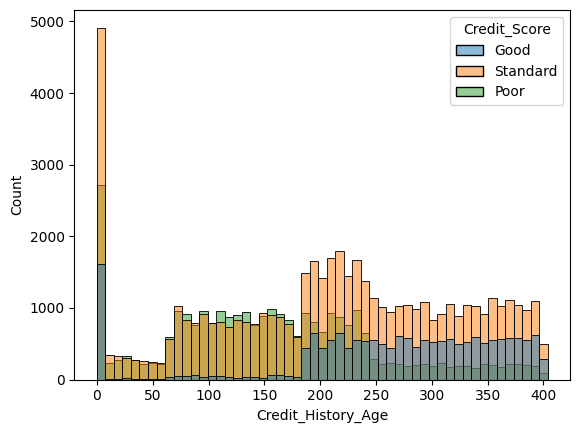

In [153]:
sns.histplot(data=train,x='Credit_History_Age',hue='Credit_Score')

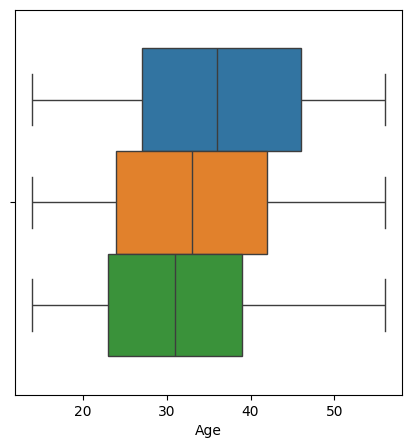

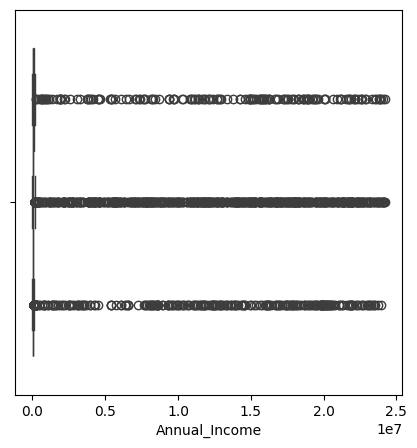

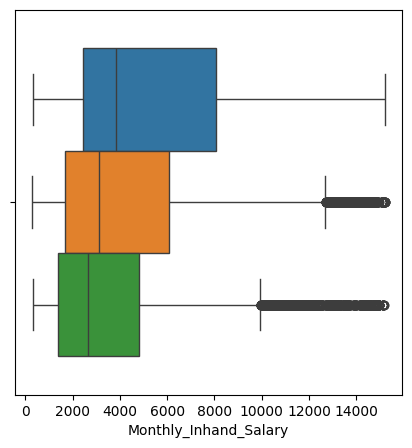

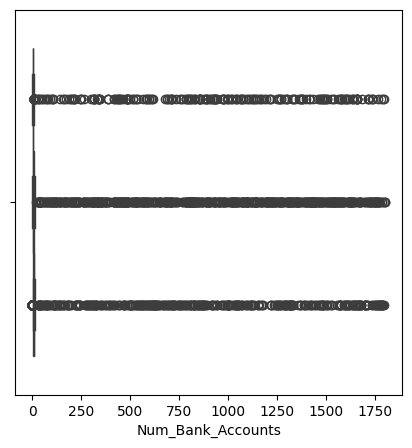

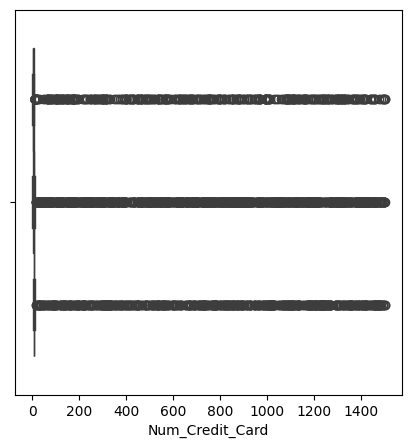

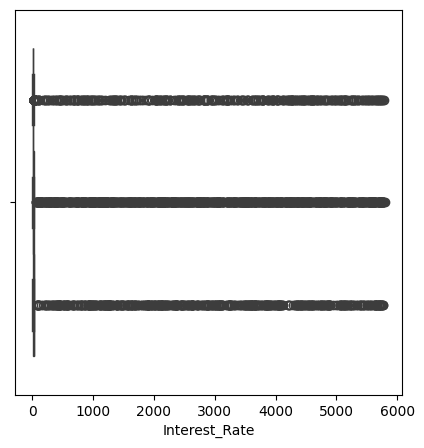

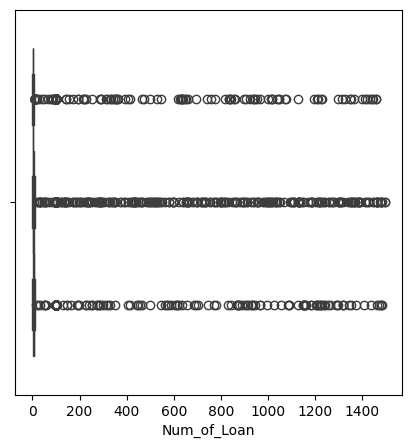

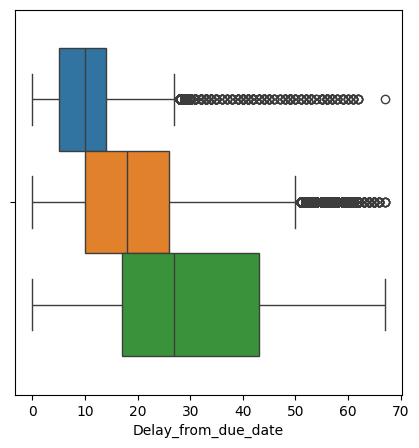

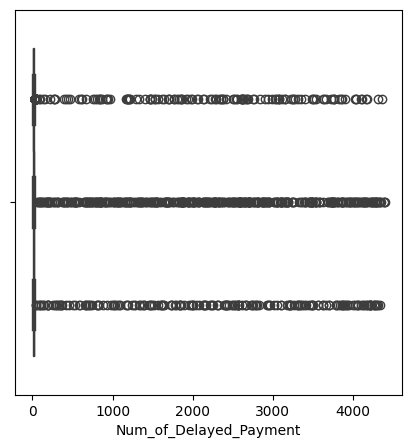

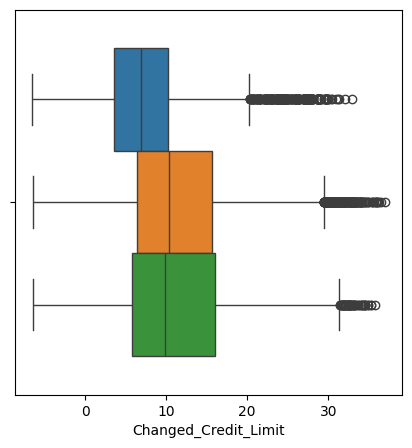

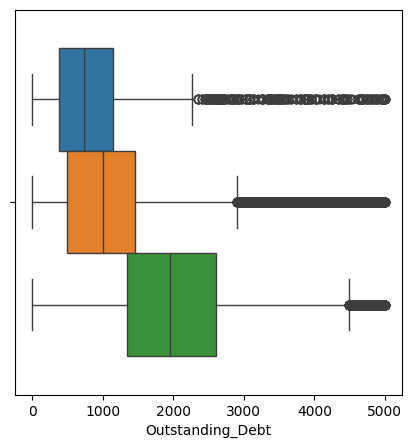

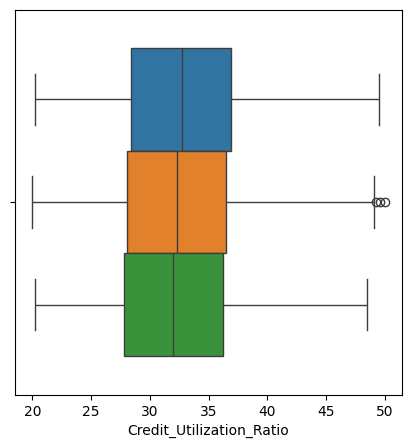

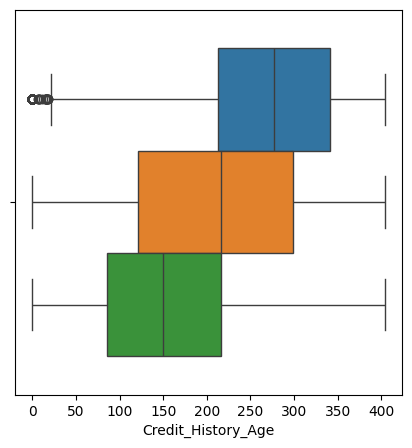

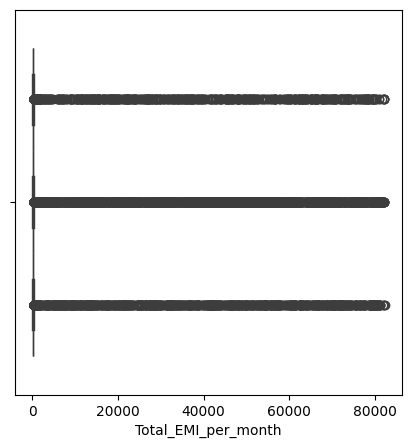

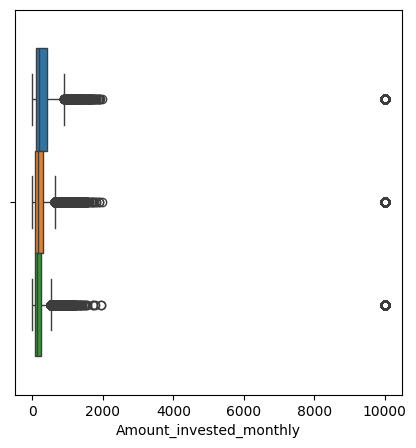

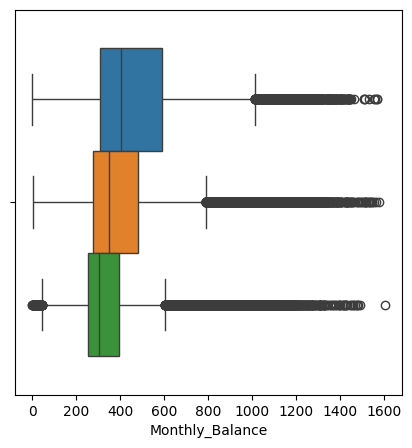

In [159]:
for col in train.select_dtypes('number').columns:
    plt.figure(figsize=(5, 5))
    ax=sns.boxplot(data=train,x=col,hue='Credit_Score')
    ax.legend_.remove()
    plt.show()

In [104]:
train['Credit_Score'].value_counts()

,count
Credit_Score,
Standard,53174
Poor,28998
Good,17828


In [121]:
train['Credit_Score'].replace({'Standard':1,'Poor':0,'Good':2},inplace=True)

<Axes: >

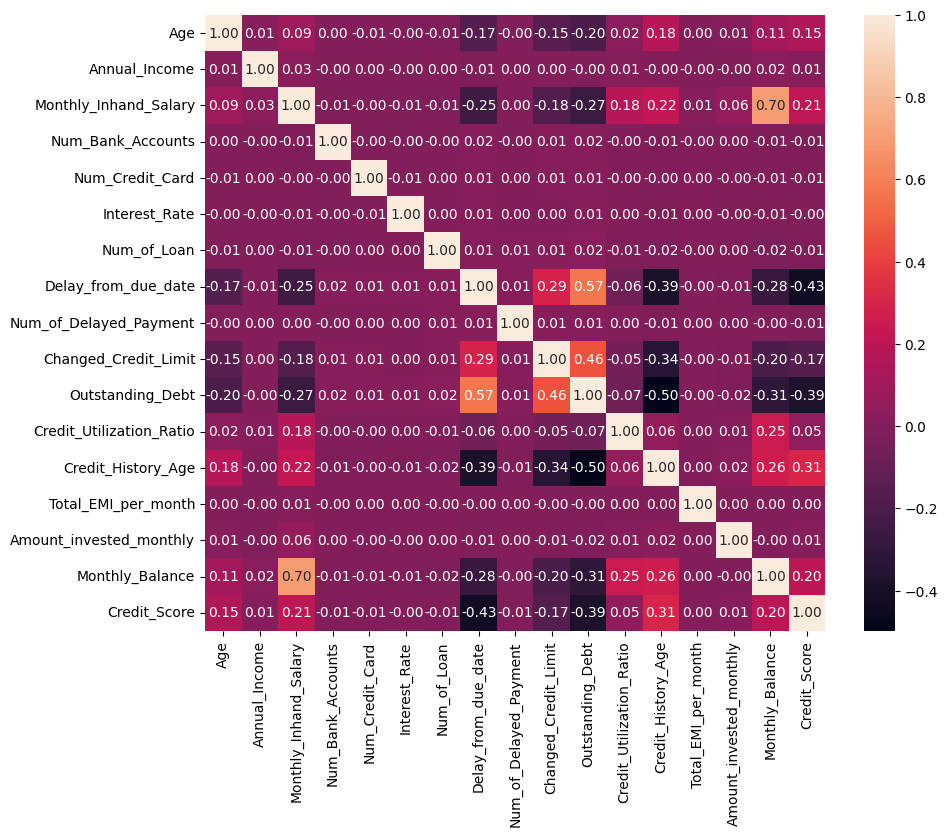

In [122]:
plt.figure(figsize=(10, 8))
sns.heatmap(train.select_dtypes('number').corr(),annot=True,fmt=".2f")

# data spliting

In [474]:
fin_train,fin_val=train_test_split(train,test_size=0.2,random_state=1234)

# convert categorical values to numerical

In [475]:
categorical_columns = ['Credit_Mix','Payment_Behaviour','Payment_of_Min_Amount']

In [476]:
for col in categorical_columns:
    fin_train[col] = fin_train[col].astype(str)

In [477]:
fin_train['Occupation'].value_counts()

,count
Occupation,
Lawyer,5528
Engineer,5336
Architect,5327
Developer,5305
Scientist,5292
Accountant,5291
Mechanic,5251
Media_Manager,5242
Entrepreneur,5230


In [478]:
fin_train['Occupation'].unique()

array(['Musician', 'Architect', 'Lawyer', 'Accountant', 'Engineer',
       'Developer', 'Mechanic', 'Journalist', 'Teacher', 'Writer',
       'Doctor', 'Scientist', 'Media_Manager', 'Manager', 'Entrepreneur'],
      dtype=object)

In [479]:
fin_train['Occupation'].replace({'Mechanic':0, 'Teacher':4, 'Engineer':5, 'Manager':6, 'Accountant':7,
       'Developer':8, 'Entrepreneur':9, 'Journalist':10, 'Doctor':11, 'Musician':12,
       'Writer':13, 'Scientist':14, 'Lawyer':15, 'Media_Manager':16, 'Architect':17},inplace=True)

In [480]:
fin_train['Month'].unique()

array(['May', 'February', 'June', 'April', 'March', 'July', 'August',
       'January'], dtype=object)

In [481]:
fin_train['Month'].replace({'February':2, 'July':7, 'June':6, 'May':5, 'August':8, 'April':4, 'January':1,
       'March':3},inplace=True)

In [482]:
# Initialize OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(fin_train[categorical_columns])
one_hot_df = pd.DataFrame(one_hot_encoded,
                          columns=encoder.get_feature_names_out(categorical_columns))




In [132]:
one_hot_df

,Credit_Mix_Bad,Credit_Mix_Good,Credit_Mix_Other,Credit_Mix_Standard,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments,Payment_Behaviour_Other,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
78322,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
78323,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
78324,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
78325,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [355]:
fin_train.shape

(78327, 28)

In [356]:
fin_train=fin_train.drop(categorical_columns, axis=1)

# Outliers

In [357]:
def outlier_percentage_iqr(df):
    outlier_percentages = {}
    for column in train.select_dtypes(include=['number']):
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = ((train[column] < lower_bound) | (df[column] > upper_bound)).sum()
        outlier_percentages[column] = (outliers / len(train)) * 100
    return outlier_percentages

outlier_percentages = outlier_percentage_iqr(fin_train)
outlier_percentages


{'Age': 0.0,
 'Annual_Income': 2.2091942518052474,
 'Monthly_Inhand_Salary': 1.596380312330838,
 'Num_Bank_Accounts': 1.054039975895985,
 'Num_Credit_Card': 1.8139292608442534,
 'Interest_Rate': 1.602508451725582,
 'Num_of_Loan': 3.4613774014646257,
 'Delay_from_due_date': 3.237700313556466,
 'Num_of_Delayed_Payment': 0.5893227384612242,
 'Changed_Credit_Limit': 0.6087285132112472,
 'Outstanding_Debt': 4.188583276307592,
 'Credit_Utilization_Ratio': 0.0040854262631627326,
 'Credit_History_Age': 0.0,
 'Total_EMI_per_month': 5.4703857663749,
 'Amount_invested_monthly': 6.583664423086743,
 'Monthly_Balance': 6.227210981625795,
 'Credit_Score': 0.0}

# feature Scaling

In [137]:
dropped_column=['ID','Customer_ID','Name','SSN','Type_of_Loan']

In [138]:
train_new=fin_train.drop(dropped_column, axis=1)

In [139]:
train_new.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_Score
31924,5,36,12,11482.565,1128.880417,4,3,10,3,19,30,8.05,3.0,517.07,39.025506,188,15.370863,99.095500,288.421679,1
73569,2,20,17,60829.800,5207.150000,4,5,2,3,7,3,0.64,2.0,445.39,27.256532,386,106.318502,10000.000000,261.902129,2
79701,6,22,15,69014.480,5467.206667,10,6,25,7,43,22,14.28,12.0,2313.63,34.523405,186,310.140346,474.844574,31.735747,0
36137,2,40,7,30802.790,2691.899167,5,5,5,3,9,4,9.18,2.0,388.92,23.255068,310,72.863201,111.120765,345.205950,2
64619,4,32,15,16481.715,1537.476250,7,3,15,6,11,9,9.59,8.0,145.32,33.985609,115,66.681222,129.228354,237.838049,1


In [148]:
train_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 78327 entries, 31924 to 94956
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     78327 non-null  int64  
 1   Age                       78327 non-null  int64  
 2   Occupation                78327 non-null  int64  
 3   Annual_Income             78327 non-null  float64
 4   Monthly_Inhand_Salary     78327 non-null  float64
 5   Num_Bank_Accounts         78327 non-null  int64  
 6   Num_Credit_Card           78327 non-null  int64  
 7   Interest_Rate             78327 non-null  int64  
 8   Num_of_Loan               78327 non-null  int64  
 9   Delay_from_due_date       78327 non-null  int64  
 10  Num_of_Delayed_Payment    78327 non-null  int64  
 11  Changed_Credit_Limit      78327 non-null  float64
 12  Num_Credit_Inquiries      78327 non-null  object 
 13  Outstanding_Debt          78327 non-null  float64
 14  Credit_

In [358]:
train_target=train_new['Credit_Score']

In [359]:
new_train=train_new[['Monthly_Inhand_Salary','Num_Bank_Accounts','Num_Credit_Card','Interest_Rate','Num_of_Loan','Delay_from_due_date',
'Num_of_Delayed_Payment','Changed_Credit_Limit','Total_EMI_per_month','Amount_invested_monthly','Monthly_Balance','Outstanding_Debt']]


In [360]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
scaled_new_train=scaler.fit_transform(new_train)

In [361]:
data_2=pd.DataFrame(scaled_new_train,columns=new_train.columns)
data_2.head()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Outstanding_Debt
0,-0.454630,-0.50,-0.666667,-0.250000,0.00,0.055556,1.5,-0.142255,-0.410143,-0.193987,-0.254297,-0.470039
1,0.487050,-0.50,0.000000,-0.916667,0.00,-0.611111,-1.2,-0.923077,0.281755,43.444506,-0.389068,-0.521983
2,0.547097,1.00,0.333333,1.000000,1.00,1.388889,0.7,0.514226,1.832361,1.462136,-1.558761,0.831863
3,-0.093726,-0.25,0.000000,-0.666667,0.00,-0.500000,-1.1,-0.023182,0.027239,-0.140986,0.034277,-0.562904
4,-0.360285,0.25,-0.666667,0.166667,0.75,-0.388889,-0.6,0.020021,-0.019792,-0.061176,-0.511361,-0.739433


In [362]:
df1_reset = data_2.reset_index(drop=True)
df2_reset = one_hot_df.reset_index(drop=True)

# Concatenate or merge them as needed, for example:
new_data = pd.concat([df1_reset, df2_reset], axis=1)

new_data

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Total_EMI_per_month,Amount_invested_monthly,...,Credit_Mix_Standard,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments,Payment_Behaviour_Other,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes
0,-0.454630,-0.50,-0.666667,-0.250000,0.00,0.055556,1.5,-0.142255,-0.410143,-0.193987,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.487050,-0.50,0.000000,-0.916667,0.00,-0.611111,-1.2,-0.923077,0.281755,43.444506,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.547097,1.00,0.333333,1.000000,1.00,1.388889,0.7,0.514226,1.832361,1.462136,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,-0.093726,-0.25,0.000000,-0.666667,0.00,-0.500000,-1.1,-0.023182,0.027239,-0.140986,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.360285,0.25,-0.666667,0.166667,0.75,-0.388889,-0.6,0.020021,-0.019792,-0.061176,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78322,-0.529031,0.00,1.666667,0.833333,-0.25,0.111111,0.0,0.161222,-0.417699,-0.486592,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
78323,0.483665,0.25,0.333333,0.416667,24.25,0.666667,1.0,-0.618546,1.310705,-0.211710,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
78324,-0.354129,0.00,1.333333,0.833333,1.50,1.333333,0.8,-0.056902,0.123823,-0.333048,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
78325,0.695032,-0.75,-0.666667,-0.250000,0.00,-0.388889,0.3,0.827187,0.294256,0.195953,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [363]:
fin_data=pd.DataFrame(train_new[['Age','Month','Occupation','Credit_History_Age']])
fin_data

,Age,Month,Occupation,Credit_History_Age
31924,36,5,12,188
73569,20,2,17,386
79701,22,6,15,186
36137,40,2,7,310
64619,32,4,15,115
...,...,...,...,...
91363,20,4,9,74
61896,35,1,15,176
34785,21,2,5,149
59289,40,2,14,64


In [364]:
fin_data.reset_index(drop=True,inplace=True)
new_data.reset_index(drop=True,inplace=True)
final_data=pd.concat([fin_data,new_data],axis=1)
final_data.head()

,Age,Month,Occupation,Credit_History_Age,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Credit_Mix_Standard,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments,Payment_Behaviour_Other,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes
0,36,5,12,188,-0.454630,-0.50,-0.666667,-0.250000,0.00,0.055556,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,20,2,17,386,0.487050,-0.50,0.000000,-0.916667,0.00,-0.611111,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,22,6,15,186,0.547097,1.00,0.333333,1.000000,1.00,1.388889,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,40,2,7,310,-0.093726,-0.25,0.000000,-0.666667,0.00,-0.500000,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,32,4,15,115,-0.360285,0.25,-0.666667,0.166667,0.75,-0.388889,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [365]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78327 entries, 0 to 78326
Data columns (total 29 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Age                                                 78327 non-null  int64  
 1   Month                                               78327 non-null  int64  
 2   Occupation                                          78327 non-null  int64  
 3   Credit_History_Age                                  78327 non-null  int64  
 4   Monthly_Inhand_Salary                               78327 non-null  float64
 5   Num_Bank_Accounts                                   78327 non-null  float64
 6   Num_Credit_Card                                     78327 non-null  float64
 7   Interest_Rate                                       78327 non-null  float64
 8   Num_of_Loan                                         78327 non-null  float64


# Feature selection

In [454]:
# from correlation matrix
features=final_data[['Age', 'Month', 'Occupation', 'Credit_History_Age',
                    'Monthly_Inhand_Salary','Delay_from_due_date','Monthly_Balance',
                     'Outstanding_Debt','Changed_Credit_Limit','Num_of_Loan', 'Credit_Mix_Good', 'Credit_Mix_Standard',
       'Payment_of_Min_Amount_Yes', 'Payment_of_Min_Amount_No',
       'Credit_Mix_Bad']]

# Prepare Test Set

Apply the data transformations you used on the training set to the test set.

**Important Note:** DO NOT use `fit` on the test set.

In [366]:
fin_val['Occupation'].replace({'Mechanic':0, 'Teacher':4, 'Engineer':5, 'Manager':6, 'Accountant':7,
       'Developer':8, 'Entrepreneur':9, 'Journalist':10, 'Doctor':11, 'Musician':12,
       'Writer':13, 'Scientist':14, 'Lawyer':15, 'Media_Manager':16, 'Architect':17},inplace=True)

In [367]:
fin_val['Month'].replace({'February':2, 'July':7, 'June':6, 'May':5, 'August':8, 'April':4, 'January':1,
       'March':3},inplace=True)

In [368]:
fin_val.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [369]:
fin_val.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,1973
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


In [370]:
one_hot_encoded_val = encoder.transform(fin_val[categorical_columns])
one_hot_df_val = pd.DataFrame(one_hot_encoded_val,
                          columns=encoder.get_feature_names_out(categorical_columns))




In [377]:
new_val=fin_val[['Monthly_Inhand_Salary','Num_Bank_Accounts','Num_Credit_Card','Interest_Rate','Num_of_Loan','Delay_from_due_date',
'Num_of_Delayed_Payment','Changed_Credit_Limit','Total_EMI_per_month','Amount_invested_monthly','Monthly_Balance','Outstanding_Debt']]


In [378]:
new_vall=['Monthly_Inhand_Salary','Num_Bank_Accounts','Num_Credit_Card','Interest_Rate','Num_of_Loan','Delay_from_due_date',
'Num_of_Delayed_Payment','Changed_Credit_Limit','Total_EMI_per_month','Amount_invested_monthly','Monthly_Balance','Outstanding_Debt']


In [379]:
vall=fin_val.drop(new_vall,axis=1)

In [380]:
vall=vall[['Age','Month','Occupation','Credit_History_Age']]
vall.isna().sum()

,0
Age,0
Month,0
Occupation,0
Credit_History_Age,0


In [382]:
scaled_new_val=scaler.transform(new_val)

In [383]:
data_2_val=pd.DataFrame(scaled_new_val,columns=new_val.columns)
data_2_val.head()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Outstanding_Debt
0,-0.464004,-0.50,0.666667,-0.750000,-0.50,-0.555556,0.8,-0.127503,-0.451895,-0.174532,-0.269470,-0.066466
1,-0.268766,-0.25,0.333333,-0.833333,0.25,-0.555556,-1.5,-0.122234,-0.225831,-0.410646,0.078186,0.112156
2,-0.033105,-1.25,0.333333,-0.416667,-0.25,0.333333,-1.1,-0.253952,-0.114264,43.444506,0.231682,-0.305844
3,1.364637,-0.50,-0.666667,-0.166667,0.00,-0.500000,-1.0,0.026344,0.745641,0.859857,1.610122,-0.191782
4,1.390878,0.25,0.333333,0.416667,-0.50,-0.722222,0.5,0.917808,352.026802,0.959940,2.166511,-0.833450


In [384]:
df1_reset = data_2_val.reset_index(drop=True)
df2_reset = one_hot_df_val.reset_index(drop=True)
new_val = pd.concat([df1_reset, df2_reset], axis=1)

new_val

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Total_EMI_per_month,Amount_invested_monthly,...,Credit_Mix_Standard,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments,Payment_Behaviour_Other,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes
0,-0.464004,-0.50,0.666667,-0.750000,-0.50,-0.555556,0.8,-0.127503,-0.451895,-0.174532,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,-0.268766,-0.25,0.333333,-0.833333,0.25,-0.555556,-1.5,-0.122234,-0.225831,-0.410646,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,-0.033105,-1.25,0.333333,-0.416667,-0.25,0.333333,-1.1,-0.253952,-0.114264,43.444506,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.364637,-0.50,-0.666667,-0.166667,0.00,-0.500000,-1.0,0.026344,0.745641,0.859857,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.390878,0.25,0.333333,0.416667,-0.50,-0.722222,0.5,0.917808,352.026802,0.959940,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19577,-0.032470,-0.50,-1.333333,-0.916667,-0.50,-0.166667,-0.5,-0.595364,-0.377125,-0.253468,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
19578,-0.171966,0.00,0.000000,0.416667,1.50,0.111111,1.5,1.133825,0.537908,2.179602,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
19579,0.905124,1.00,0.666667,0.333333,1.00,0.611111,0.5,0.665964,2.584751,0.041426,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
19580,-0.238155,-1.00,0.333333,-0.666667,-0.25,0.277778,-0.5,-0.501581,-0.318248,-0.197603,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [385]:
vall.shape

(19582, 4)

In [386]:
new_val.shape

(19582, 25)

In [387]:
new_val = new_val.reset_index(drop=True)
vall = vall.reset_index(drop=True)
new_val[['Age','Month','Occupation','Credit_History_Age']]=vall[['Age','Month','Occupation','Credit_History_Age']]
new_val.isna().sum()


,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0
Num_Credit_Card,0
Interest_Rate,0
Num_of_Loan,0
Delay_from_due_date,0
Num_of_Delayed_Payment,0
Changed_Credit_Limit,0
Total_EMI_per_month,0
Amount_invested_monthly,0


In [396]:
val=new_val[['Age', 'Month', 'Occupation', 'Credit_History_Age',
                    'Monthly_Inhand_Salary','Delay_from_due_date','Monthly_Balance',
                     'Outstanding_Debt','Changed_Credit_Limit','Num_of_Loan', 'Credit_Mix_Good', 'Credit_Mix_Standard',
       'Payment_of_Min_Amount_Yes', 'Payment_of_Min_Amount_No',
       'Credit_Mix_Bad']]

In [397]:
val.isna().sum()

,0
Age,0
Month,0
Occupation,0
Credit_History_Age,0
Monthly_Inhand_Salary,0
Delay_from_due_date,0
Monthly_Balance,0
Outstanding_Debt,0
Changed_Credit_Limit,0
Num_of_Loan,0


----------------------

# `05` Logistic Regression

Using `sklearn` implementation of logistic regression to model the data.

Hint: Look for `sklearn.linear_model.LogisticRegression` class.

## `i` Baseline Model Training

Initializing the model with initial parameters, fitting it to the training data, and get a baseline model.

Use:
- Non-regularized model.
- `random_state` $= 1234$

In [398]:
features.head()

,Age,Month,Occupation,Credit_History_Age,Monthly_Inhand_Salary,Delay_from_due_date,Monthly_Balance,Outstanding_Debt,Changed_Credit_Limit,Num_of_Loan,Credit_Mix_Good,Credit_Mix_Standard,Payment_of_Min_Amount_Yes,Payment_of_Min_Amount_No,Credit_Mix_Bad
0,36,5,12,188,-0.454630,0.055556,-0.254297,-0.470039,-0.142255,0.00,0.0,1.0,0.0,1.0,0.0
1,20,2,17,386,0.487050,-0.611111,-0.389068,-0.521983,-0.923077,0.00,1.0,0.0,0.0,1.0,0.0
2,22,6,15,186,0.547097,1.388889,-1.558761,0.831863,0.514226,1.00,0.0,0.0,1.0,0.0,1.0
3,40,2,7,310,-0.093726,-0.500000,0.034277,-0.562904,-0.023182,0.00,1.0,0.0,0.0,1.0,0.0
4,32,4,15,115,-0.360285,-0.388889,-0.511361,-0.739433,0.020021,0.75,0.0,1.0,1.0,0.0,0.0


In [399]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78327 entries, 0 to 78326
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        78327 non-null  int64  
 1   Month                      78327 non-null  int64  
 2   Occupation                 78327 non-null  int64  
 3   Credit_History_Age         78327 non-null  int64  
 4   Monthly_Inhand_Salary      78327 non-null  float64
 5   Delay_from_due_date        78327 non-null  float64
 6   Monthly_Balance            78327 non-null  float64
 7   Outstanding_Debt           78327 non-null  float64
 8   Changed_Credit_Limit       78327 non-null  float64
 9   Num_of_Loan                78327 non-null  float64
 10  Credit_Mix_Good            78327 non-null  float64
 11  Credit_Mix_Standard        78327 non-null  float64
 12  Payment_of_Min_Amount_Yes  78327 non-null  float64
 13  Payment_of_Min_Amount_No   78327 non-null  flo

In [400]:
train_target

,Credit_Score
31924,1
73569,2
79701,0
36137,2
64619,1
...,...
91363,0
61896,1
34785,0
59289,1


In [401]:

lR=LogisticRegression(penalty=None,random_state=1234,class_weight='balanced')
lR.fit(features,train_target)

LogisticRegression(class_weight='balanced', penalty=None, random_state=1234)

## `ii` Model Evaluation

Evaluate the baseline model performance using classification metrics, e.g. **Accuracy**, **Precision**, $F_1 \space Score$, **Confusion Matrix** etc.

Which metric is more reliable?

In [402]:
lR.score(features,train_target)

0.609227980134564

In [403]:
y_pred=lR.predict(val)

In [404]:
val_target=fin_val['Credit_Score']

In [405]:

accuracy_score(val_target,y_pred)

0.6073434787049331

In [406]:
precision_score(val_target,y_pred,average='weighted')

0.6649877391078479

In [407]:
f1_score(val_target,y_pred,average='weighted')

0.6102978377638751

In [408]:
confusion_matrix(val_target,y_pred)

array([[3602, 1110,  939],
       [2288, 5335, 2813],
       [  93,  446, 2956]])

<Axes: >

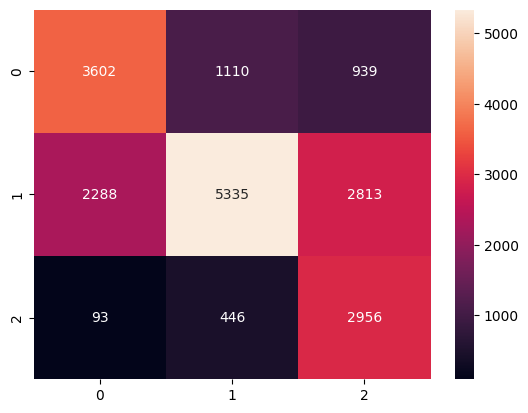

In [409]:
sns.heatmap(confusion_matrix(val_target,y_pred),annot=True,fmt="d")

## `iii` Regularization Mode: On

Let's try the default $l_2$ regularization. Use default $C$ parameter for simplicity. Does regularization make the model generalize better?

`Bonus:` You can use `solver='saga'` parameter to be able to try the $l_1$ regularization and compare the two.

In [423]:
lR=LogisticRegression(penalty='l2',C=1,random_state=1234,class_weight='balanced')
lR.fit(features,train_target)


LogisticRegression(C=1, class_weight='balanced', random_state=1234)

In [424]:
lR.score(features,train_target)

0.610364242215328

In [425]:
y_pred=lR.predict(val)

In [426]:
print('accuracy_score=',accuracy_score(val_target,y_pred))
print('precision_score=',precision_score(val_target,y_pred,average='weighted'))
print('f1_score=',f1_score(val_target,y_pred,average='weighted'))


accuracy_score= 0.6079052190787458
precision_score= 0.6593435574661829
f1_score= 0.6111171191065876


- Solver saga

In [427]:
lR=LogisticRegression(penalty='l1',C=1,solver='saga',random_state=1234)
lR.fit(features,train_target)


LogisticRegression(C=1, penalty='l1', random_state=1234, solver='saga')

In [429]:
lR.score(features,train_target)


0.6179350670905307

In [430]:
y_pred=lR.predict(val)

In [431]:
print('accuracy_score=',accuracy_score(val_target,y_pred))
print('precision_score=',precision_score(val_target,y_pred,average='weighted'))
print('f1_score=',f1_score(val_target,y_pred,average='weighted'))


accuracy_score= 0.6193442957818405
precision_score= 0.620862660598767
f1_score= 0.6137105903594163


## `iv` Tuning Hyperparameters

1. Try different `C` values and evaluate. What is the best panalty value?
2. Try training the model while using the `class_weight` parameter and compare the results. Did it affect the model evaluation?
3. You can tune other parameters as you see fit (but make sure you elaborate your reasoning).

`Note:` Remember that $alpha=\frac{1}{C}$ which means less regularization for higher $C$ values.

`Hint:` You might want to use `sklearn.model_selection.RandomizedSearchCV` or `sklearn.model_selection.GridSearchCV` classes.

In [432]:
lR=LogisticRegression(solver='sag',random_state=1234,class_weight="balanced")
lR.fit(features,train_target)


LogisticRegression(class_weight='balanced', random_state=1234, solver='sag')

In [433]:
lR.score(features,train_target)


0.623169532855848

In [434]:
y_pred=lR.predict(val)

In [435]:
print('accuracy_score=',accuracy_score(val_target,y_pred))
print('precision_score=',precision_score(val_target,y_pred,average='weighted'))
print('f1_score=',f1_score(val_target,y_pred,average='weighted'))


accuracy_score= 0.6231232764783985
precision_score= 0.6653246554114526
f1_score= 0.6262116888653296


-----------------------------

# `06` Logistic Regression with Gradient Descent

The `LogisticRegression` class optimizes the model paramters via solvers (e.g., `lbfgs`, `saga`, etc.) instead of using gradient descent.

If we want to train the logistic regression model using gradient descent we can use `SGDClassifier` and tune the parameters almost the same way we did with `SGDRegressor`.

Try this and do hyperparameter tuning if needed to decide which model is better.

`Notes:`
- You will have to set `loss='log_loss'` to use `SGDClassifier` as a logistic regression model.
- The `alpha` parameter is the inverse of the `C` parameter and hence bigger values will result in more regularization.



In [487]:
sgd_LR = SGDClassifier(
    loss='log_loss',
    random_state=1234,
    learning_rate='constant',
    eta0=0.01,
    class_weight="balanced",
    max_iter=500
    )
sgd_LR.fit(features,train_target)

SGDClassifier(class_weight='balanced', eta0=0.01, learning_rate='constant',
              loss='log_loss', max_iter=500, random_state=1234)

In [488]:
sgd_LR.score(features,train_target)


0.5809618650018512

In [489]:
y_pred=sgd_LR.predict(val)

In [490]:
print('accuracy_score=',accuracy_score(val_target,y_pred))
print('precision_score=',precision_score(val_target,y_pred,average='weighted'))
print('f1_score=',f1_score(val_target,y_pred,average='weighted'))


accuracy_score= 0.5791032580941681
precision_score= 0.5691409582441375
f1_score= 0.52981002270554


------------------

# `07` Generalization Error

Now that we have tuned our solution, to an *extent*, we need to test for a final time on the held out test set.

In [506]:
test.head()
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        50000 non-null  object 
 1   Customer_ID               50000 non-null  object 
 2   Month                     50000 non-null  object 
 3   Name                      44985 non-null  object 
 4   Age                       50000 non-null  object 
 5   SSN                       50000 non-null  object 
 6   Occupation                50000 non-null  object 
 7   Annual_Income             50000 non-null  object 
 8   Monthly_Inhand_Salary     42502 non-null  float64
 9   Num_Bank_Accounts         50000 non-null  int64  
 10  Num_Credit_Card           50000 non-null  int64  
 11  Interest_Rate             50000 non-null  int64  
 12  Num_of_Loan               50000 non-null  object 
 13  Type_of_Loan              44296 non-null  object 
 14  Delay_

In [507]:
test['Age'] = test['Age'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)
test['Age']=test['Age'].astype(int)

In [508]:
test['Month'].replace({'February':2, 'July':7, 'June':6, 'May':5, 'August':8, 'April':4, 'January':1,
       'March':3},inplace=True)

In [509]:
test.groupby('Customer_ID')['Occupation'].value_counts().reset_index(name='Count')


,Customer_ID,Occupation,Count
0,CUS_0x1000,Lawyer,4
1,CUS_0x1009,Mechanic,4
2,CUS_0x100b,Media_Manager,3
3,CUS_0x100b,_______,1
4,CUS_0x1011,Doctor,4
...,...,...,...
15596,CUS_0xff4,_______,1
15597,CUS_0xff6,Doctor,4
15598,CUS_0xffc,Musician,3
15599,CUS_0xffc,_______,1


In [510]:
occupation_mapping = test[test['Occupation'] != "_______"].groupby('Customer_ID')['Occupation'].first()
test['Occupation'] = test.apply(lambda row: occupation_mapping[row['Customer_ID']] if row['Occupation'] == "_______" else row['Occupation'], axis=1)


In [511]:
test['Occupation'].replace({'Mechanic':0, 'Teacher':4, 'Engineer':5, 'Manager':6, 'Accountant':7,
       'Developer':8, 'Entrepreneur':9, 'Journalist':10, 'Doctor':11, 'Musician':12,
       'Writer':13, 'Scientist':14, 'Lawyer':15, 'Media_Manager':16, 'Architect':17},inplace=True)

In [528]:
test['Month'].replace({'February':2, 'July':7, 'June':6, 'May':5, 'August':8, 'April':4, 'January':1,
       'March':3,'September':9,'December':12,'October':10,'November':11},inplace=True)

In [529]:
test['Month'].unique()

array([ 9, 10, 11, 12])

In [513]:
test['Credit_History_Age'].fillna('Unknown',inplace=True)
history_age = []
for i in range(test.shape[0]):
    if ('Years and') in test['Credit_History_Age'].values[i]:
        splitted = test['Credit_History_Age'].values[i].split('Years and')
        years = int(splitted[0].strip())
        months = int(splitted[1].replace('Months', ''))
        history_age.append((years * 12) + months)
    else:
        history_age.append(0)

test['Credit_History_Age'] = history_age

In [548]:
Salary=test.groupby('Customer_ID')['Monthly_Inhand_Salary'].first()
test['Monthly_Inhand_Salary'] = test['Monthly_Inhand_Salary'].fillna(test['Customer_ID'].map(Salary))

In [549]:
test['Monthly_Inhand_Salary'].fillna(0,inplace=True)

In [515]:
test['Delay_from_due_date'] = test['Delay_from_due_date'].apply(lambda x: abs(x) if x<0 else x)

In [516]:
test['Monthly_Balance']=test['Monthly_Balance'].apply(lambda x:'nan' if x=='__-333333333333333333333333333__' else x)
test['Monthly_Balance']=test['Monthly_Balance'].astype(float)
test['Monthly_Balance'].fillna(test['Monthly_Balance'].mean(),inplace=True)


In [517]:
test['Outstanding_Debt'] = test['Outstanding_Debt'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)
test['Outstanding_Debt']=test['Outstanding_Debt'].astype(float)


In [518]:
test['Changed_Credit_Limit']=test['Changed_Credit_Limit'].apply(lambda x:'nan' if x=='_' else x)
test['Changed_Credit_Limit'] = imputer.fit_transform(test[['Changed_Credit_Limit']])
test['Changed_Credit_Limit']=test['Changed_Credit_Limit'].astype(float)



In [519]:
test['Num_of_Loan'] = test['Num_of_Loan'].apply(lambda x: str(x).rstrip('_') if str(x).endswith('_') else x)
test['Num_of_Loan']=test['Num_of_Loan'].astype(int)

In [520]:
test['Payment_of_Min_Amount']=test['Payment_of_Min_Amount'].apply(lambda x: 'No' if x=='NM' else x)

In [521]:
test['Credit_Mix']=test['Credit_Mix'].apply(lambda x:'Other' if x=='_' else x )

In [522]:
test['Payment_Behaviour']=test['Payment_Behaviour'].apply(lambda x:'Other' if x=='!@9#%8' else x)

In [523]:
one_hot_encoded = encoder.transform(test[categorical_columns])
one_hot_df_test = pd.DataFrame(one_hot_encoded,
                          columns=encoder.get_feature_names_out(categorical_columns))



In [550]:
new_test=test[['Age', 'Month', 'Occupation', 'Credit_History_Age',
                    'Monthly_Inhand_Salary','Delay_from_due_date','Monthly_Balance',
                     'Outstanding_Debt','Changed_Credit_Limit','Num_of_Loan']]
one_test=one_hot_df_test[['Credit_Mix_Good', 'Credit_Mix_Standard',
       'Payment_of_Min_Amount_Yes', 'Payment_of_Min_Amount_No',
       'Credit_Mix_Bad']]

new_test.reset_index(drop=True,inplace=True)
one_test.reset_index(drop=True,inplace=True)
final_test=pd.concat([new_test,one_test],axis=1)
final_test.head()

,Age,Month,Occupation,Credit_History_Age,Monthly_Inhand_Salary,Delay_from_due_date,Monthly_Balance,Outstanding_Debt,Changed_Credit_Limit,Num_of_Loan,Credit_Mix_Good,Credit_Mix_Standard,Payment_of_Min_Amount_Yes,Payment_of_Min_Amount_No,Credit_Mix_Bad
0,23,9,14,273,0,3,186.266702,809.98,11.27,4,1.0,0.0,0.0,1.0,0.0
1,24,10,14,274,0,3,361.444004,809.98,13.27,4,1.0,0.0,0.0,1.0,0.0
2,24,11,14,0,0,1,264.675446,809.98,12.27,4,1.0,0.0,0.0,1.0,0.0
3,24,12,14,276,0,4,343.826873,809.98,11.27,4,1.0,0.0,0.0,1.0,0.0
4,28,9,4,327,0,3,485.298434,605.03,5.42,1,1.0,0.0,0.0,1.0,0.0


In [551]:
final_test.isna().sum()

,0
Age,0
Month,0
Occupation,0
Credit_History_Age,0
Monthly_Inhand_Salary,0
Delay_from_due_date,0
Monthly_Balance,0
Outstanding_Debt,0
Changed_Credit_Limit,0
Num_of_Loan,0


In [552]:
y_test=sgd_LR.predict(final_test)

In [556]:
y_test

array([0, 0, 0, ..., 0, 0, 0])

-----------------------------

# `Bonus` Better Flow

For the model to be production-ready, we need to integrate it into a pipeline along with the data preparation flow.

Hint: Look up `sklearn.pipeline.Pipeline` class.

In [448]:
sgd = Pipeline([
    ('model', SGDClassifier(
        loss='log_loss',
        random_state=1234,
        learning_rate='adaptive',
        eta0=0.001,
        class_weight="balanced"
    ))
])


In [449]:
cv_scores = cross_val_score(sgd, features, train_target, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean accuracy:", cv_scores.mean())

Cross-validation scores: [0.62677135 0.62581386 0.61627833 0.62419406 0.62400255]
Mean accuracy: 0.6234120321070361


In [450]:
sgd.fit(features,train_target)

Pipeline(steps=[('model',
                 SGDClassifier(class_weight='balanced', eta0=0.001,
                               learning_rate='adaptive', loss='log_loss',
                               random_state=1234))])

In [451]:
sgd.score(features,train_target)

0.6250462803375592

In [452]:
y_pred=sgd_LR.predict(val)

In [453]:
print('accuracy_score=',accuracy_score(val_target,y_pred))
print('precision_score=',precision_score(val_target,y_pred,average='weighted'))
print('f1_score=',f1_score(val_target,y_pred,average='weighted'))


accuracy_score= 0.5791032580941681
precision_score= 0.5691409582441375
f1_score= 0.52981002270554


----------------------------------------------

$$ Wish \space you \space all \space the \space best \space ♡ $$
$$ Abdelrahman \space Eid $$